# Emotion Detection with Vision Transformer (ViT) in PyTorch

**Architecture:** Vision Transformer (ViT-Base/7) built from scratch, without pretrained weights.  
**Dataset:** `./dataset` with `train`, `validation`, and `test` folders.

---
## 1. Import Libraries

In [11]:
import json
import os
import random
from collections import defaultdict

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:   {torch.cuda.is_available()}')
print(f'MPS available:    {torch.backends.mps.is_available()}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device:           {DEVICE}')

PyTorch version: 2.12.0
CUDA available:   False
MPS available:    True
Device:           mps


---
## 2. Dataset Configuration & Loading

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

DATASET_ROOT = '../dataset'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
VALIDATION_DIR = os.path.join(DATASET_ROOT, 'validation')
TEST_DIR = os.path.join(DATASET_ROOT, 'test')

IMG_SIZE = 48
PATCH_SIZE = 6       # 48 / 6 = 8 patches per row/col → 64 patches total
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 5e-4
NUM_CLASSES = 8
NUM_WORKERS = 0

EMOTIONS = sorted(os.listdir(TRAIN_DIR))
print(f'Detected {len(EMOTIONS)} emotion classes: {EMOTIONS}')

for split_name, path in [('Train', TRAIN_DIR), ('Validation', VALIDATION_DIR), ('Test', TEST_DIR)]:
    total = sum(len(os.listdir(os.path.join(path, emotion))) for emotion in EMOTIONS)
    print(f'{split_name:12s}: {total:,} images  ({total // len(EMOTIONS)} per class)')

Detected 8 emotion classes: ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']
Train       : 16,000 images  (2000 per class)
Validation  : 3,200 images  (400 per class)
Test        : 3,200 images  (400 per class)


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASETS AND DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        shear=0.1,
        scale=(0.9, 1.1),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08)),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
validation_dataset = datasets.ImageFolder(VALIDATION_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

class_to_idx = train_dataset.class_to_idx
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
class_names = [idx_to_class[idx] for idx in range(NUM_CLASSES)]

pin_memory = DEVICE.type == 'cuda'
loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=pin_memory)
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_kwargs,
)
validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

print('\nClass → Index mapping:')
for name, idx in class_to_idx.items():
    print(f'  {idx}: {name}')

print(f'\nTrain samples:      {len(train_dataset):,}')
print(f'Validation samples: {len(validation_dataset):,}')
print(f'Test samples:       {len(test_dataset):,}')


Class → Index mapping:
  0: Anger
  1: Contempt
  2: Disgust
  3: Fear
  4: Happiness
  5: Neutral
  6: Sadness
  7: Surprise

Train samples:      16,000
Validation samples: 3,200
Test samples:       3,200


---
## 3. Data Visualization

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────

required_names = {'checkpoint_path', 'model', 'predict_loader', 'test_loader'}
if required_names.issubset(globals()):
    if os.path.exists(checkpoint_path):
        best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(best_checkpoint['model_state_dict'])
        print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}.")

    print('Generating predictions on test set ...')
    y_prob, y_true, y_pred = predict_loader(test_loader)

    print(f'\nTrue labels shape : {y_true.shape}')
    print(f'Pred labels shape : {y_pred.shape}')
else:
    print('Skipping test-set prediction preview until the model and training utilities are defined.')

Generating predictions on test set ...

True labels shape : (3200,)
Pred labels shape : (3200,)


---
## 4. Build Vision Transformer (ViT) from Scratch

**Vision Transformer (ViT)** applies the standard Transformer architecture directly to image patches, treating each patch as a "token" analogous to a word in NLP.  
For an image of size **H×W** with patch size **P×P**, the number of patches is: $N = \frac{H \times W}{P^2}$

Each patch is linearly projected into a **D-dimensional embedding**, then a learnable **[CLS] token** and **positional embeddings** are added.  
The sequence is processed by **L Transformer encoder blocks**, each containing:
- **Multi-Head Self-Attention (MHSA):** $\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$
- **Feed-Forward Network (FFN):** two-layer MLP with GELU activation
- **Layer Norm** applied before each sub-layer (Pre-LN)

**ViT-Base/7 configuration (adapted for 48×48 input):**
| Hyperparameter | Value |
|----------------|-------|
| Image size | 48×48 |
| Patch size | 6×6 |
| Number of patches (N) | 64 |
| Embedding dimension (D) | 256 |
| Encoder depth (L) | 8 |
| Attention heads | 8 |
| MLP hidden dim | 512 |
| Dropout | 0.1 |

Adapted for **48×48 input** with a small patch size of **6×6** to preserve spatial resolution, yielding 64 patches per image.

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# VISION TRANSFORMER (ViT) BUILT FROM SCRATCH IN PYTORCH
# ─────────────────────────────────────────────────────────────────────────────


class PatchEmbedding(nn.Module):
    """Split image into non-overlapping patches and linearly embed each patch."""

    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        assert img_size % patch_size == 0, (
            f'Image size {img_size} must be divisible by patch size {patch_size}.'
        )
        self.num_patches = (img_size // patch_size) ** 2
        # Use a Conv2d with kernel=patch_size and stride=patch_size as the
        # patch projection: each non-overlapping patch → one embed_dim vector.
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size,
            bias=False,
        )

    def forward(self, x):
        # x: (B, C, H, W)  →  projection: (B, D, H/P, W/P)
        x = self.projection(x)          # (B, D, n, n)
        x = x.flatten(2)               # (B, D, N)  where N = n*n
        x = x.transpose(1, 2)          # (B, N, D)
        return x


class MultiHeadSelfAttention(nn.Module):
    """Scaled dot-product multi-head self-attention."""

    def __init__(self, embed_dim, num_heads, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, (
            f'embed_dim {embed_dim} must be divisible by num_heads {num_heads}.'
        )
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, D = x.shape
        # Compute Q, K, V in one shot and reshape to (B, heads, N, head_dim)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)   # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)             # each: (B, heads, N, head_dim)

        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, D)  # (B, N, D)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class FeedForward(nn.Module):
    """Position-wise feed-forward network: Linear → GELU → Dropout → Linear → Dropout."""

    def __init__(self, embed_dim, mlp_dim, drop=0.0):
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, mlp_dim)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(drop)
        self.fc2 = nn.Linear(mlp_dim, embed_dim)
        self.drop2 = nn.Dropout(drop)

    def forward(self, x):
        x = self.drop1(self.act(self.fc1(x)))
        x = self.drop2(self.fc2(x))
        return x


class TransformerEncoderBlock(nn.Module):
    """Single Transformer encoder block with Pre-LayerNorm."""

    def __init__(self, embed_dim, num_heads, mlp_dim, attn_drop=0.0, drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff    = FeedForward(embed_dim, mlp_dim, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))  # residual
        x = x + self.ff(self.norm2(x))    # residual
        return x


class ViTScratch(nn.Module):
    """
    Vision Transformer built from scratch in PyTorch, adapted for 48×48
    grayscale-sourced (3-channel) emotion images.

    Using patch size 6×6 gives 64 non-overlapping patches per image,
    which is a compact but expressive token sequence for a small dataset.

    Architecture:
        Patch Embedding : 64 patches × 256-dim
        + [CLS] token  → sequence length = 65
        + Positional Embedding (learnable, 65 × 256)
        8 × TransformerEncoderBlock (embed=256, heads=8, mlp=512)
        LayerNorm
        CLS token → Linear(256, num_classes)
    """

    def __init__(
        self,
        img_size=48,
        patch_size=6,
        in_channels=3,
        num_classes=8,
        embed_dim=256,
        depth=8,
        num_heads=8,
        mlp_dim=512,
        dropout_rate=0.1,
    ):
        super().__init__()

        # ── Patch embedding ────────────────────────────────────────────────
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches  # e.g. 64

        # ── Learnable [CLS] token and positional embedding ─────────────────
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout_rate)

        # ── Transformer encoder ────────────────────────────────────────────
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                attn_drop=dropout_rate,
                drop=dropout_rate,
            )
            for _ in range(depth)
        ])

        # ── Classification head ────────────────────────────────────────────
        self.norm       = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        # Positional embedding: truncated normal
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        # CLS token
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        # All linear layers: truncated normal; all LayerNorms: identity init
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)
            elif isinstance(module, nn.LayerNorm):
                nn.init.constant_(module.weight, 1.0)
                nn.init.constant_(module.bias, 0.0)
            elif isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')

    def forward(self, x):
        B = x.shape[0]

        # Patch embedding: (B, N, D)
        x = self.patch_embed(x)

        # Prepend [CLS] token: (B, N+1, D)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Add positional embedding and apply dropout
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # Transformer encoder blocks
        for block in self.blocks:
            x = block(x)

        # Final layer norm
        x = self.norm(x)

        # Classify using [CLS] token representation
        cls_out = x[:, 0]           # (B, D)
        return self.classifier(cls_out)


def build_vit(
    img_size=48,
    patch_size=6,
    in_channels=3,
    num_classes=8,
    embed_dim=256,
    depth=8,
    num_heads=8,
    mlp_dim=512,
    dropout_rate=0.1,
):
    return ViTScratch(
        img_size=img_size,
        patch_size=patch_size,
        in_channels=in_channels,
        num_classes=num_classes,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_dim=mlp_dim,
        dropout_rate=dropout_rate,
    )


model = build_vit(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=3,
    num_classes=NUM_CLASSES,
    embed_dim=256,
    depth=8,
    num_heads=8,
    mlp_dim=512,
    dropout_rate=0.1,
).to(DEVICE)

num_parameters = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f'\nTrainable parameters: {num_parameters:,}')

ViTScratch(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(6, 6), stride=(6, 6), bias=False)
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-7): 8 x TransformerEncoderBlock(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=False)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (proj_drop): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (ff): FeedForward(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.1, inplace=False)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (drop2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (n

---
## 5. Compile & Train the Model

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# VISION TRANSFORMER (ViT) BUILT FROM SCRATCH IN PYTORCH
# ─────────────────────────────────────────────────────────────────────────────


class PatchEmbedding(nn.Module):
    """Split image into non-overlapping patches and linearly embed each patch."""

    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        assert img_size % patch_size == 0, (
            f'Image size {img_size} must be divisible by patch size {patch_size}.'
        )
        self.num_patches = (img_size // patch_size) ** 2
        # Use a Conv2d with kernel=patch_size and stride=patch_size as the
        # patch projection: each non-overlapping patch → one embed_dim vector.
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size,
            bias=False,
        )

    def forward(self, x):
        # x: (B, C, H, W)  →  projection: (B, D, H/P, W/P)
        x = self.projection(x)          # (B, D, n, n)
        x = x.flatten(2)                # (B, D, N)  where N = n*n
        x = x.transpose(1, 2)          # (B, N, D)
        return x


class MultiHeadSelfAttention(nn.Module):
    """Scaled dot-product multi-head self-attention."""

    def __init__(self, embed_dim, num_heads, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, (
            f'embed_dim {embed_dim} must be divisible by num_heads {num_heads}.'
        )
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, D = x.shape
        # Compute Q, K, V in one shot and reshape to (B, heads, N, head_dim)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)   # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)             # each: (B, heads, N, head_dim)

        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, D)  # (B, N, D)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class FeedForward(nn.Module):
    """Position-wise feed-forward network: Linear → GELU → Dropout → Linear → Dropout."""

    def __init__(self, embed_dim, mlp_dim, drop=0.0):
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, mlp_dim)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(drop)
        self.fc2 = nn.Linear(mlp_dim, embed_dim)
        self.drop2 = nn.Dropout(drop)

    def forward(self, x):
        x = self.drop1(self.act(self.fc1(x)))
        x = self.drop2(self.fc2(x))
        return x


class TransformerEncoderBlock(nn.Module):
    """Single Transformer encoder block with Pre-LayerNorm."""

    def __init__(self, embed_dim, num_heads, mlp_dim, attn_drop=0.0, drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff    = FeedForward(embed_dim, mlp_dim, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))  # residual
        x = x + self.ff(self.norm2(x))    # residual
        return x


class ViTScratch(nn.Module):
    """
    Vision Transformer built from scratch in PyTorch, adapted for 48×48
    grayscale-sourced (3-channel) emotion images.

    Using patch size 6×6 gives 64 non-overlapping patches per image,
    which is a compact but expressive token sequence for a small dataset.

    Architecture:
        Patch Embedding : 64 patches × 256-dim
        + [CLS] token  → sequence length = 65
        + Positional Embedding (learnable, 65 × 256)
        8 × TransformerEncoderBlock (embed=256, heads=8, mlp=512)
        LayerNorm
        Classifier: 256 → num_classes
    """

    def __init__(
        self,
        img_size=48,
        patch_size=6,
        in_channels=3,
        num_classes=8,
        embed_dim=256,
        depth=8,
        num_heads=8,
        mlp_dim=512,
        dropout_rate=0.05,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout_rate)

        self.encoder = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                attn_drop=dropout_rate,
                drop=dropout_rate,
            )
            for _ in range(depth)
        ])

        self.norm       = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)  # (B, N, D)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Add positional embedding and apply dropout
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for block in self.encoder:
            x = block(x)

        x = self.norm(x)
        cls_output = x[:, 0]  # CLS token
        logits = self.classifier(cls_output)
        return logits


def build_vit(
    img_size=48,
    patch_size=6,
    in_channels=3,
    num_classes=8,
    embed_dim=256,
    depth=8,
    num_heads=8,
    mlp_dim=512,
    dropout_rate=0.05,
):
    return ViTScratch(
        img_size=img_size,
        patch_size=patch_size,
        in_channels=in_channels,
        num_classes=num_classes,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_dim=mlp_dim,
        dropout_rate=dropout_rate,
    )


model = build_vit(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=3,
    num_classes=NUM_CLASSES,
    embed_dim=256,
    depth=8,
    num_heads=8,
    mlp_dim=512,
    dropout_rate=0.05,
).to(DEVICE)

num_parameters = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f'\nTrainable parameters: {num_parameters:,}')

ViTScratch(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(6, 6), stride=(6, 6), bias=False)
  )
  (pos_drop): Dropout(p=0.05, inplace=False)
  (encoder): ModuleList(
    (0-7): 8 x TransformerEncoderBlock(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=False)
        (attn_drop): Dropout(p=0.05, inplace=False)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (proj_drop): Dropout(p=0.05, inplace=False)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (ff): FeedForward(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.05, inplace=False)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (drop2): Dropout(p=0.05, inplace=False)
      )
    )
  

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN
# ─────────────────────────────────────────────────────────────────────────────

history = defaultdict(list)
best_val_acc = 0.0
best_val_loss = float('inf')
best_val_acc_epoch = 0
best_val_loss_epoch = 0
patience = 15
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(validation_loader, training=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_acc_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'class_to_idx': class_to_idx,
                'img_size': IMG_SIZE,
                'num_classes': NUM_CLASSES,
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_loss_epoch = epoch

    print(
        f'Epoch {epoch:02d}/{EPOCHS:02d} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.2e}'
    )

    if epochs_without_improvement >= patience:
        print(f'Early stopping triggered after {epoch} epochs.')
        break

if os.path.exists(checkpoint_path):
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f'\nLoaded best model from epoch {best_checkpoint["epoch"]} with val accuracy {best_checkpoint["best_val_acc"]:.4f}.')

print('\n✅ Training complete!')

Epoch 01/100 | train_loss=2.1098 train_acc=0.1242 | val_loss=2.1295 val_acc=0.0950 | lr=4.91e-04
Epoch 02/100 | train_loss=2.1112 train_acc=0.1230 | val_loss=2.1295 val_acc=0.0950 | lr=4.67e-04
Epoch 03/100 | train_loss=2.1099 train_acc=0.1267 | val_loss=2.1295 val_acc=0.0950 | lr=4.27e-04
Epoch 04/100 | train_loss=2.1099 train_acc=0.1240 | val_loss=2.1295 val_acc=0.0950 | lr=3.75e-04
Epoch 05/100 | train_loss=2.1095 train_acc=0.1264 | val_loss=2.1295 val_acc=0.0950 | lr=3.15e-04
Epoch 06/100 | train_loss=2.1086 train_acc=0.1244 | val_loss=2.1295 val_acc=0.0950 | lr=2.51e-04
Epoch 07/100 | train_loss=2.1119 train_acc=0.1235 | val_loss=2.1295 val_acc=0.0950 | lr=1.86e-04
Epoch 08/100 | train_loss=2.1112 train_acc=0.1246 | val_loss=2.1295 val_acc=0.0950 | lr=1.26e-04
Epoch 09/100 | train_loss=2.1116 train_acc=0.1253 | val_loss=2.1295 val_acc=0.0950 | lr=7.41e-05
Epoch 10/100 | train_loss=2.1071 train_acc=0.1266 | val_loss=2.1295 val_acc=0.0950 | lr=3.44e-05
Epoch 11/100 | train_loss=2.10

---
## 6. Training vs Validation — Accuracy & Loss Curves

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTIMISATION, SCHEDULING, AND HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
# CosineAnnealingWarmRestarts keeps the transformer moving while validation plateaus are explored.
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=12, T_mult=2, eta_min=1e-6)
checkpoint_path = 'best_vit_emotion.pt'


def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=pin_memory)
        labels = labels.to(DEVICE, non_blocking=pin_memory)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        predictions = outputs.argmax(dim=1)
        running_correct += (predictions == labels).sum().item()
        running_total += batch_size

    avg_loss = running_loss / running_total
    avg_acc = running_correct / running_total
    return avg_loss, avg_acc


def predict_loader(loader):
    model.eval()
    all_probs = []
    all_true = []
    all_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=pin_memory)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            all_probs.append(probs.cpu().numpy())
            all_true.append(labels.numpy())
            all_pred.append(preds.cpu().numpy())

    return (
        np.concatenate(all_probs, axis=0),
        np.concatenate(all_true, axis=0),
        np.concatenate(all_pred, axis=0),
    )

In [19]:
# Quick sanity check: single-batch forward pass to validate model and transforms
try:
    model.eval()
    images, labels = next(iter(train_loader))
    images = images.to(DEVICE)
    outputs = model(images)
    print('Output shape:', outputs.shape)
    print('Sample logits (first row):', outputs[0][:5].detach().cpu().numpy())
except Exception as e:
    print('Sanity check failed:', repr(e))


Output shape: torch.Size([32, 8])
Sample logits (first row): [-0.0995992  -0.4740824   0.16181597 -0.13979505 -0.1766926 ]


In [20]:
# Quick training sanity run on a small subset (few batches)
try:
    subset_idx = list(range(min(64, len(train_dataset))))
    subset = torch.utils.data.Subset(train_dataset, subset_idx)
    tmp_loader = DataLoader(subset, batch_size=min(BATCH_SIZE, 32), shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
    train_loss, train_acc = run_epoch(tmp_loader, training=True)
    print('Quick train pass — loss:', train_loss, 'acc:', train_acc)
except Exception as e:
    print('Quick training sanity failed:', repr(e))


Quick train pass — loss: 1.453289806842804 acc: 0.46875


---
## 7. Performance Metrics

Evaluate on the **held-out test set** (never seen during training or validation).

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE PREDICTIONS ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────

if 'predict_loader' not in globals():
    raise RuntimeError('Run the training utilities cell before this evaluation cell.')

if os.path.exists(checkpoint_path):
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']}.")

print('Generating predictions on test set ...')
y_prob, y_true, y_pred = predict_loader(test_loader)

# Map indices back to class names
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f'\nTrue labels shape : {y_true.shape}')
print(f'Pred labels shape : {y_pred.shape}')

Loaded best checkpoint from epoch 1.
Generating predictions on test set ...

True labels shape : (3200,)
Pred labels shape : (3200,)


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# OVERALL METRICS
# ─────────────────────────────────────────────────────────────────────────────

acc = accuracy_score(y_true, y_pred)
prec_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_w = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
prec_m = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec_m = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_m = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 60)
print('           OVERALL PERFORMANCE METRICS (Test Set)')
print('=' * 60)
print(f'  Accuracy                        : {acc:.4f}  ({acc * 100:.2f}%)')
print()
print(f'  Weighted Precision               : {prec_w:.4f}')
print(f'  Weighted Recall                  : {rec_w:.4f}')
print(f'  Weighted F1-Score                : {f1_w:.4f}')
print()
print(f'  Macro Precision                  : {prec_m:.4f}')
print(f'  Macro Recall                     : {rec_m:.4f}')
print(f'  Macro F1-Score                   : {f1_m:.4f}')
print('=' * 60)

           OVERALL PERFORMANCE METRICS (Test Set)
  Accuracy                        : 0.1459  (14.59%)

  Weighted Precision               : 0.1463
  Weighted Recall                  : 0.1459
  Weighted F1-Score                : 0.1019

  Macro Precision                  : 0.1463
  Macro Recall                     : 0.1459
  Macro F1-Score                   : 0.1019


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# PER-CLASS CLASSIFICATION REPORT
# ─────────────────────────────────────────────────────────────────────────────

print('\nDetailed Classification Report:')
print('-' * 60)
report_str = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report_str)

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)


Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       Anger     0.4067    0.2725    0.3263       400
    Contempt     0.0000    0.0000    0.0000       400
     Disgust     0.1892    0.0350    0.0591       400
        Fear     0.0980    0.0125    0.0222       400
   Happiness     0.1031    0.0250    0.0402       400
     Neutral     0.1182    0.0325    0.0510       400
     Sadness     0.1198    0.6950    0.2044       400
    Surprise     0.1357    0.0950    0.1118       400

    accuracy                         0.1459      3200
   macro avg     0.1463    0.1459    0.1019      3200
weighted avg     0.1463    0.1459    0.1019      3200



In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN
# ─────────────────────────────────────────────────────────────────────────────

# Ensure required helpers and optimisation objects are available before training.
_required = ['run_epoch', 'optimizer', 'scheduler', 'predict_loader']
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        'Missing required objects: ' + ', '.join(_missing) + 
        ". Run the 'OPTIMISATION, SCHEDULING, AND HELPER FUNCTIONS' cell (above) or execute the notebook top-to-bottom."
    )

history = defaultdict(list)
best_val_acc = 0.0
best_val_loss = float('inf')
best_val_acc_epoch = 0
best_val_loss_epoch = 0
patience = 25
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(validation_loader, training=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_acc_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'class_to_idx': class_to_idx,
                'img_size': IMG_SIZE,
                'num_classes': NUM_CLASSES,
            },
            checkpoint_path,
        )
    else:
        epochs_without_improvement += 1

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_loss_epoch = epoch

    print(
        f'Epoch {epoch:02d}/{EPOCHS:02d} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | '
        f'lr={optimizer.param_groups[0]["lr"]:.2e}'
    )

    if epochs_without_improvement >= patience:
        print(f'Early stopping triggered after {epoch} epochs.')
        break

if os.path.exists(checkpoint_path):
    best_checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f"\nLoaded best model from epoch {best_checkpoint['epoch']} with val accuracy {best_checkpoint['best_val_acc']:.4f}.")
else:
    print('Best checkpoint not found; continuing with the final model weights.')

Epoch 01/100 | train_loss=2.0649 train_acc=0.1677 | val_loss=2.2746 val_acc=0.1303 | lr=4.91e-04
Epoch 02/100 | train_loss=2.0200 train_acc=0.2003 | val_loss=2.2080 val_acc=0.1197 | lr=4.67e-04
Epoch 03/100 | train_loss=1.9775 train_acc=0.2279 | val_loss=2.2681 val_acc=0.1338 | lr=4.27e-04
Epoch 04/100 | train_loss=1.9244 train_acc=0.2611 | val_loss=2.2893 val_acc=0.1338 | lr=3.75e-04
Epoch 05/100 | train_loss=1.8602 train_acc=0.2991 | val_loss=2.1304 val_acc=0.2128 | lr=3.15e-04
Epoch 06/100 | train_loss=1.7659 train_acc=0.3482 | val_loss=2.0702 val_acc=0.2350 | lr=2.51e-04
Epoch 07/100 | train_loss=1.6681 train_acc=0.3891 | val_loss=2.1517 val_acc=0.2500 | lr=1.86e-04
Epoch 08/100 | train_loss=1.5691 train_acc=0.4333 | val_loss=2.2802 val_acc=0.2437 | lr=1.26e-04
Epoch 09/100 | train_loss=1.4669 train_acc=0.4793 | val_loss=2.2038 val_acc=0.2797 | lr=7.41e-05
Epoch 10/100 | train_loss=1.3991 train_acc=0.5073 | val_loss=2.1744 val_acc=0.3259 | lr=3.44e-05
Epoch 11/100 | train_loss=1.34

KeyboardInterrupt: 

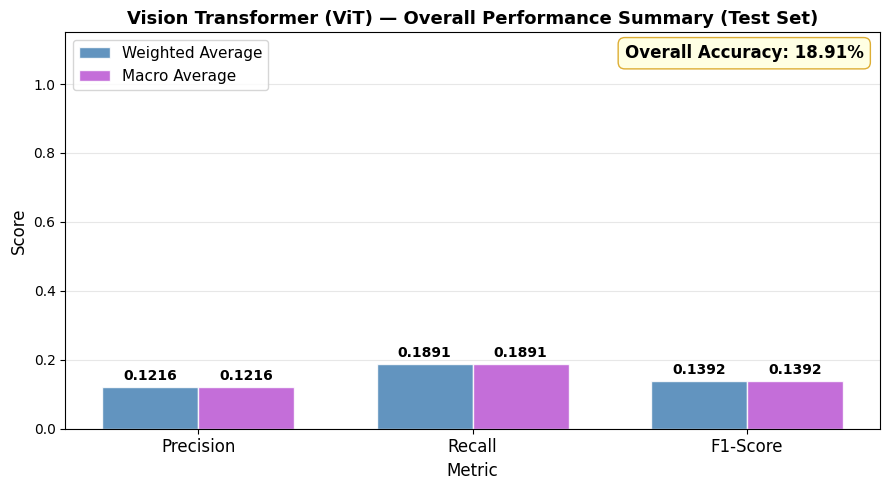

Plot saved as summary_metrics.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY DASHBOARD — Weighted vs Macro comparison
# ─────────────────────────────────────────────────────────────────────────────

metrics_labels = ['Precision', 'Recall', 'F1-Score']
weighted_scores = [prec_w, rec_w, f1_w]
macro_scores = [prec_m, rec_m, f1_m]

x2 = np.arange(len(metrics_labels))
width2 = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x2 - width2 / 2, weighted_scores, width2, label='Weighted Average', color='steelblue', alpha=0.85, edgecolor='white')
b2 = ax.bar(x2 + width2 / 2, macro_scores, width2, label='Macro Average', color='mediumorchid', alpha=0.85, edgecolor='white')

ax.set_title('Vision Transformer (ViT) — Overall Performance Summary (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x2)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in list(b1) + list(b2):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.annotate(
    f'Overall Accuracy: {acc * 100:.2f}%',
    xy=(0.98, 0.97),
    xycoords='axes fraction',
    ha='right',
    va='top',
    fontsize=12,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='goldenrod', alpha=0.9),
)

plt.tight_layout()
plt.savefig('summary_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as summary_metrics.png')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL CONSOLIDATED SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

print('\n' + '=' * 72)
print('                  FINAL PERFORMANCE SUMMARY — TEST SET')
print('=' * 72)
print(f"{'Metric':<40} {'Score':>10}")
print('-' * 52)
print(f"{'Accuracy':<40} {acc:>10.4f}")
print()
print(f"{'Weighted Avg Precision':<40} {prec_w:>10.4f}")
print(f"{'Weighted Avg Recall':<40} {rec_w:>10.4f}")
print(f"{'Weighted Avg F1-Score':<40} {f1_w:>10.4f}")
print()
print(f"{'Macro Avg Precision':<40} {prec_m:>10.4f}")
print(f"{'Macro Avg Recall':<40} {rec_m:>10.4f}")
print(f"{'Macro Avg F1-Score':<40} {f1_m:>10.4f}")
print('-' * 52)
print()
print('Per-Class F1-Scores:')
for cls, f1_value in zip(class_names, per_class_f1):
    bar = '█' * int(f1_value * 30)
    print(f'  {cls:<12} {f1_value:.4f}  {bar}')
print('=' * 72)
best_val_acc_text = f'{best_val_acc:.4f} (Epoch {best_val_acc_epoch})' if 'best_val_acc' in globals() else 'N/A (run training first)'
best_val_loss_text = f'{best_val_loss:.4f} (Epoch {best_val_loss_epoch})' if 'best_val_loss' in globals() else 'N/A (run training first)'
print(f'  Best Validation Accuracy : {best_val_acc_text}')
print(f'  Best Validation Loss     : {best_val_loss_text}')
print('=' * 72)


                  FINAL PERFORMANCE SUMMARY — TEST SET
Metric                                        Score
----------------------------------------------------
Accuracy                                     0.1891

Weighted Avg Precision                       0.1216
Weighted Avg Recall                          0.1891
Weighted Avg F1-Score                        0.1392

Macro Avg Precision                          0.1216
Macro Avg Recall                             0.1891
Macro Avg F1-Score                           0.1392
----------------------------------------------------

Per-Class F1-Scores:
  Anger        0.1699  █████
  Contempt     0.6091  ██████████████████
  Disgust      0.0000  
  Fear         0.0987  ██
  Happiness    0.0000  
  Neutral      0.0000  
  Sadness      0.0139  
  Surprise     0.2220  ██████
  Best Validation Accuracy : 0.1709 (Epoch 10)
  Best Validation Loss     : 2.0804 (Epoch 6)


---
## 8. Confusion Matrix

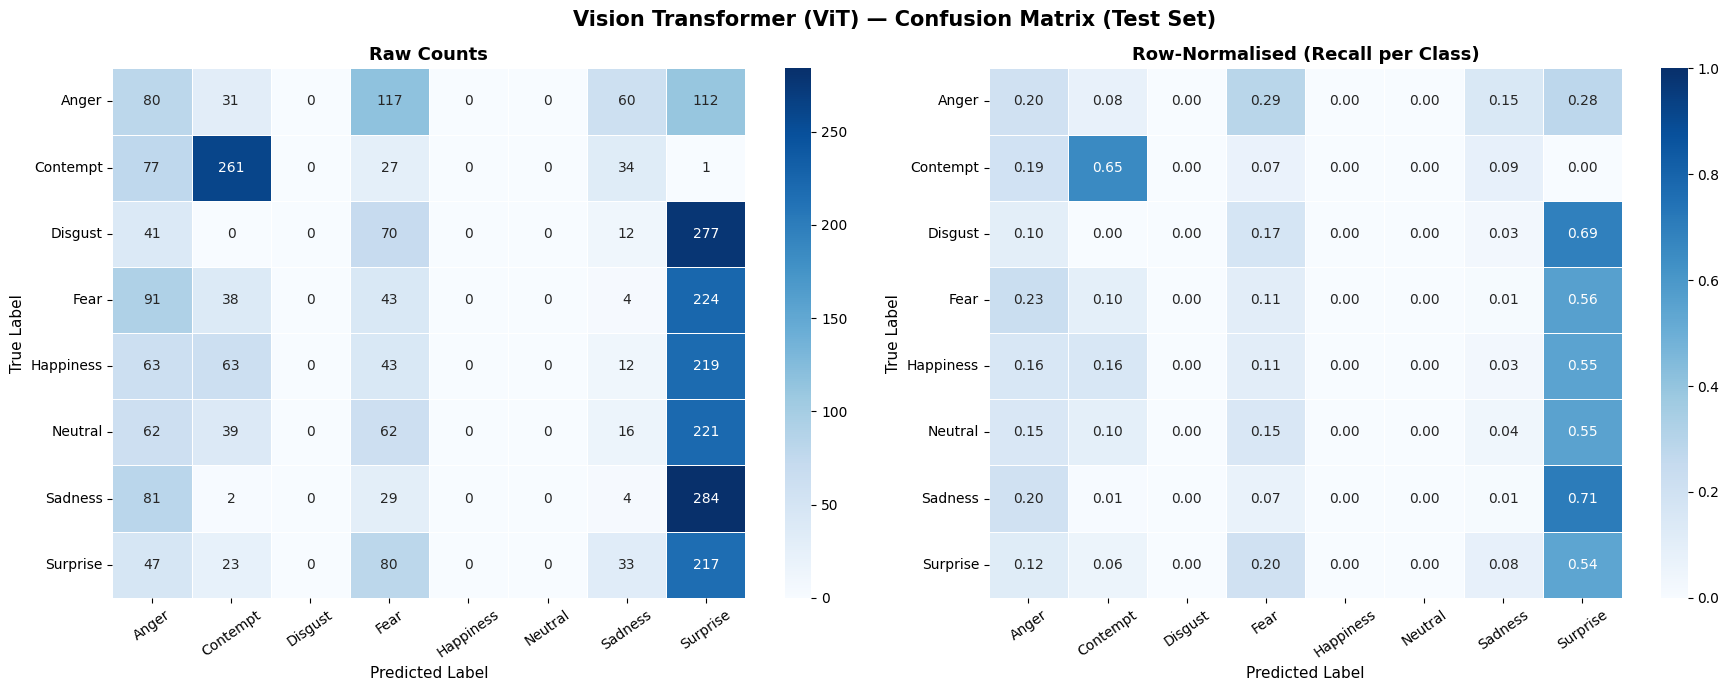

Plot saved as confusion_matrix.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Vision Transformer (ViT) — Confusion Matrix (Test Set)', fontsize=15, fontweight='bold')

# Raw counts
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, ax=axes[0],
)
axes[0].set_title('Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

# Row-normalised
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, vmin=0, vmax=1, ax=axes[1],
)
axes[1].set_title('Row-Normalised (Recall per Class)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as confusion_matrix.png')

---
## 9. Save Weights & Class Index Map

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE FINAL MODEL WEIGHTS
# ─────────────────────────────────────────────────────────────────────────────

weights_path = 'vit_emotion_weights.pt'
torch.save(model.state_dict(), weights_path)
print(f'Model weights saved → {weights_path}')

final_path = 'vit_emotion_final.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
        'img_size': IMG_SIZE,
        'patch_size': PATCH_SIZE,
        'num_classes': NUM_CLASSES,
        'best_val_acc': best_val_acc,
        'best_val_acc_epoch': best_val_acc_epoch,
    },
    final_path,
)
print(f'Full checkpoint saved  → {final_path}')

class_index_path = 'class_indices.json'
with open(class_index_path, 'w') as f:
    json.dump(class_to_idx, f, indent=2)
print(f'Class index map saved  → {class_index_path}')

Model weights saved → vit_emotion_weights.pt
Full checkpoint saved  → vit_emotion_final.pt
Class index map saved  → class_indices.json


---
## Bonus: Quick Inference on a Single Image

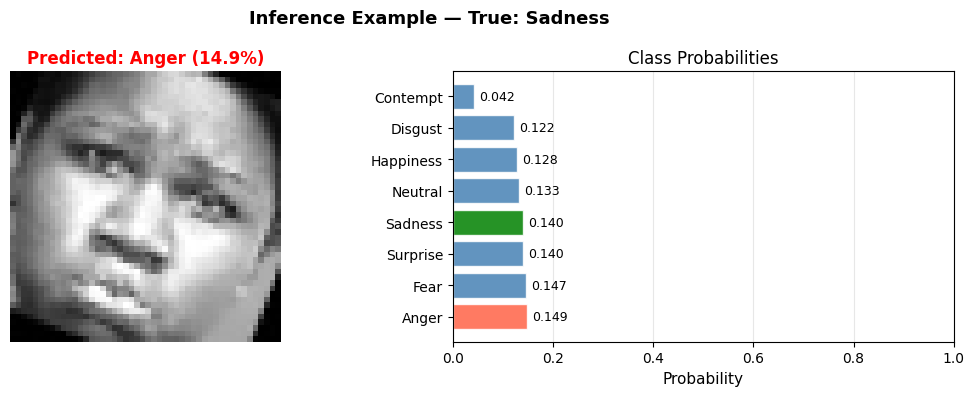

True label : Sadness
Predicted  : Anger (confidence: 14.87%)
Result     : ❌ INCORRECT


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# QUICK INFERENCE — predict emotion for one image
# ─────────────────────────────────────────────────────────────────────────────

def predict_emotion(img_path, model, idx_to_class, img_size=48, device=DEVICE):
    """Load an image, preprocess it, and return the predicted emotion."""
    image = Image.open(img_path).convert('RGB')
    image_tensor = val_test_transforms(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probabilities = torch.softmax(model(image_tensor), dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probabilities))
    predicted_class = idx_to_class[pred_idx]
    confidence = float(probabilities[pred_idx])
    all_probs = {idx_to_class[i]: float(probabilities[i]) for i in range(len(probabilities))}
    return predicted_class, confidence, all_probs


sample_path, sample_label_idx = random.choice(test_dataset.samples)
sample_emotion = idx_to_class[sample_label_idx]
pred_class, confidence, all_probs = predict_emotion(sample_path, model, idx_to_class)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f'Inference Example — True: {sample_emotion}', fontsize=13, fontweight='bold')

img_display = Image.open(sample_path).convert('RGB')
axes[0].imshow(img_display)
color = 'green' if pred_class == sample_emotion else 'red'
axes[0].set_title(f'Predicted: {pred_class} ({confidence * 100:.1f}%)', color=color, fontsize=12, fontweight='bold')
axes[0].axis('off')

sorted_probs = dict(sorted(all_probs.items(), key=lambda item: item[1], reverse=True))
bar_colors = ['green' if class_name == sample_emotion else ('steelblue' if class_name != pred_class else 'tomato') for class_name in sorted_probs.keys()]
axes[1].barh(list(sorted_probs.keys()), list(sorted_probs.values()), color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Probability', fontsize=11)
axes[1].set_title('Class Probabilities', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
for i, (class_name, probability) in enumerate(sorted_probs.items()):
    axes[1].text(probability + 0.01, i, f'{probability:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'True label : {sample_emotion}')
print(f'Predicted  : {pred_class} (confidence: {confidence * 100:.2f}%)')
correct = '✅ CORRECT' if pred_class == sample_emotion else '❌ INCORRECT'
print(f'Result     : {correct}')